# Import OneFormer

In [1]:
%cd OneFormer/
import numpy as np
import cv2
import torch
import cv2
import imutils

import sys, os, distutils.core
# !git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
# !python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])} --quiet
sys.path.insert(0, os.path.abspath('./detectron2'))

/home/sabbbir/Documents/of/OneFormer


## Detectron Import

In [2]:
######
#@title 3. Import Libraries and other Utilities
######
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
setup_logger(name="oneformer")

# Import libraries
import numpy as np
import cv2
import torch
import cv2
import imutils

# Import detectron2 utilities
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from detectron2.data import MetadataCatalog
from demo.defaults import DefaultPredictor
from demo.visualizer import Visualizer, ColorMode


# import OneFormer Project
from oneformer import (
    add_oneformer_config,
    add_common_config,
    add_swin_config,
    add_dinat_config,
    add_convnext_config,
)

######
#@title 4. Define helper functions
######
cpu_device = torch.device("cpu")
SWIN_CFG_DICT = {"cityscapes": "configs/cityscapes/oneformer_swin_large_IN21k_384_bs16_90k.yaml",
            "coco": "configs/coco/oneformer_swin_large_IN21k_384_bs16_100ep.yaml",
            "ade20k": "configs/ade20k/oneformer_swin_large_IN21k_384_bs16_160k.yaml",}

DINAT_CFG_DICT = {"cityscapes": "configs/cityscapes/oneformer_dinat_large_bs16_90k.yaml",
            "coco": "configs/coco/oneformer_dinat_large_bs16_100ep.yaml",
            "ade20k": "configs/ade20k/oneformer_dinat_large_IN21k_384_bs16_160k.yaml",}

def setup_cfg(dataset, model_path, use_swin):
    # load config from file and command-line arguments
    cfg = get_cfg()
    add_deeplab_config(cfg)
    add_common_config(cfg)
    add_swin_config(cfg)
    add_dinat_config(cfg)
    add_convnext_config(cfg)
    add_oneformer_config(cfg)
    if use_swin:
      cfg_path = SWIN_CFG_DICT[dataset]
    else:
      cfg_path = DINAT_CFG_DICT[dataset]
    cfg.merge_from_file(cfg_path)
    cfg.MODEL.DEVICE = 'cuda:0'
    cfg.MODEL.WEIGHTS = model_path
    cfg.freeze()
    return cfg

def setup_modules(dataset, model_path, use_swin):
    cfg = setup_cfg(dataset, model_path, use_swin)
    predictor = DefaultPredictor(cfg)
    metadata = MetadataCatalog.get(
        cfg.DATASETS.TEST_PANOPTIC[0] if len(cfg.DATASETS.TEST_PANOPTIC) else "__unused"
    )
    if 'cityscapes_fine_sem_seg_val' in cfg.DATASETS.TEST_PANOPTIC[0]:
        from cityscapesscripts.helpers.labels import labels
        stuff_colors = [k.color for k in labels if k.trainId != 255]
        metadata = metadata.set(stuff_colors=stuff_colors)

    return predictor, metadata

def panoptic_run(img, predictor, metadata):
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, instance_mode=ColorMode.IMAGE)
    predictions = predictor(img, "panoptic")
    panoptic_seg, segments_info = predictions["panoptic_seg"]
    out = visualizer.draw_panoptic_seg_predictions(
    panoptic_seg.to(cpu_device), segments_info, alpha=0.5
)
    return out

def instance_run(img, predictor, metadata):
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, instance_mode=ColorMode.IMAGE)
    predictions = predictor(img, "instance")
    instances = predictions["instances"].to(cpu_device)
    out = visualizer.draw_instance_predictions(predictions=instances, alpha=0.5)
    return out

def semantic_run(img, predictor, metadata):
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, instance_mode=ColorMode.IMAGE)
    predictions = predictor(img, "semantic")
    out = visualizer.draw_sem_seg(
        predictions["sem_seg"].argmax(dim=0).to(cpu_device), alpha=0.5
    )
    return out

TASK_INFER = {"panoptic": panoptic_run,
              "instance": instance_run,
              "semantic": semantic_run}

matplotlib data path: /home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/matplotlib/mpl-data
CONFIGDIR=/home/sabbbir/.config/matplotlib
interactive is False
platform is linux
CACHEDIR=/home/sabbbir/.cache/matplotlib
Using fontManager instance from /home/sabbbir/.cache/matplotlib/fontlist-v390.json
Popen(['git', 'version'], cwd=/home/sabbbir/Documents/of/OneFormer, stdin=None, shell=False, universal_newlines=False)
Popen(['git', 'version'], cwd=/home/sabbbir/Documents/of/OneFormer, stdin=None, shell=False, universal_newlines=False)
Trying paths: ['/home/sabbbir/.docker/config.json', '/home/sabbbir/.dockercfg']
No config file found
Setting up integrations (with default = False)
Setting SDK name to 'sentry.python'
[Profiling] Setting up continuous profiler in thread mode


/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sabbbir/Documents/of/OneFormer/oneformer/modeling/pixel_decoder/msdeformattn.py:314: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


# Initialize the models

In [4]:
import os
import subprocess

use_swin = True #@param {type: 'boolean'}

def city():
  """
  Initializes the OneFormer model with either DiNAT-L or Swin-L backbone
  based on the 'use_swin' global variable. Downloads the corresponding
  checkpoint if it doesn't exist.
  """
  global use_swin
  if not use_swin:
    checkpoint_path = "250_16_dinat_l_oneformer_cityscapes_90k.pth"
    checkpoint_url = "https://shi-labs.com/projects/oneformer/cityscapes/250_16_dinat_l_oneformer_cityscapes_90k.pth"
  else:
    checkpoint_path = "250_16_swin_l_oneformer_cityscapes_90k.pth"
    checkpoint_url = "https://shi-labs.com/projects/oneformer/cityscapes/250_16_swin_l_oneformer_cityscapes_90k.pth"

  if not os.path.exists(checkpoint_path):
    print(f"Downloading checkpoint: {checkpoint_path}...")
    subprocess.run(f'wget {checkpoint_url}', shell=True)
    print("Download complete.")
  else:
    print(f"Checkpoint already exists: {checkpoint_path}")

  predictor, metadata = setup_modules("cityscapes", checkpoint_path, use_swin)
  return predictor, metadata

# Example of how to call the function:
predictor, metadata = city()


def ade():
  """
  Initializes the OneFormer model for the ADE20K dataset.
  Downloads the checkpoint if it doesn't exist.
  Assumes success of download and setup.

  Returns:
      tuple: (predictor, metadata) - The initialized predictor and metadata.  May return invalid values if download or setup fails.
  """
  global use_swin
  if not use_swin:
    checkpoint_path = "250_16_dinat_l_oneformer_ade20k_160k.pth"
    checkpoint_url = "https://shi-labs.com/projects/oneformer/ade20k/250_16_dinat_l_oneformer_ade20k_160k.pth"
  else:
    checkpoint_path = "250_16_swin_l_oneformer_ade20k_160k.pth"
    checkpoint_url = "https://shi-labs.com/projects/oneformer/ade20k/250_16_swin_l_oneformer_ade20k_160k.pth"

  if not os.path.exists(checkpoint_path):
    print(f"Downloading checkpoint: {checkpoint_path}...")
    subprocess.run(['wget', checkpoint_url], check=True)
    print("Download complete.")

  predictor, metadata = setup_modules("ade20k", checkpoint_path, use_swin)
  return predictor, metadata


predictor, metadata = ade()



def coco():
  global use_swin
  if not use_swin:
    checkpoint_path = "150_16_dinat_l_oneformer_coco_100ep.pth"
    checkpoint_url = 'wget https://shi-labs.com/projects/oneformer/coco/150_16_dinat_l_oneformer_coco_100ep.pth'
  else:
    checkpoint_path = "150_16_swin_l_oneformer_coco_100ep.pth"
    checkpoint_url = "wget https://shi-labs.com/projects/oneformer/coco/150_16_swin_l_oneformer_coco_100ep.pth"

  if not os.path.exists(checkpoint_path):
    print(f"Downloading checkpoint: {checkpoint_path}...")
    subprocess.run(f'wget {checkpoint_url}', shell=True)
    print("Download complete.")
  else:
    print(f"Checkpoint already exists: {checkpoint_path}")

    predictor, metadata = setup_modules("coco", checkpoint_path, use_swin)
    return predictor, metadata



predictor, metadata = coco()

    # You would use predictor and metadata here.  No error checking.

# Now 'predictor' and 'metadata' are initialized and ready to use.
# Now 'predictor' and 'metadata' are initialized and ready to use.

Loading config configs/cityscapes/Base-Cityscapes-UnifiedSegmentation.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Checkpoint already exists: 250_16_swin_l_oneformer_cityscapes_90k.pth


/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[09/06 14:57:12 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from 250_16_swin_l_oneformer_cityscapes_90k.pth ...
[Checkpointer] Loading from 250_16_swin_l_oneformer_cityscapes_90k.pth ...


/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_

[09/06 14:57:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from 250_16_swin_l_oneformer_ade20k_160k.pth ...
[Checkpointer] Loading from 250_16_swin_l_oneformer_ade20k_160k.pth ...


The checkpoint state_dict contains keys that are not used by the model:
  text_encoder.positional_embedding
  text_encoder.transformer.resblocks.0.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.0.attn.out_proj.{bias, weight}
  text_encoder.transformer.resblocks.0.ln_1.{bias, weight}
  text_encoder.transformer.resblocks.0.mlp.c_fc.{bias, weight}
  text_encoder.transformer.resblocks.0.mlp.c_proj.{bias, weight}
  text_encoder.transformer.resblocks.0.ln_2.{bias, weight}
  text_encoder.transformer.resblocks.1.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.1.attn.out_proj.{bias, weight}
  text_encoder.transformer.resblocks.1.ln_1.{bias, weight}
  text_encoder.transformer.resblocks.1.mlp.c_fc.{bias, weight}
  text_encoder.transformer.resblocks.1.mlp.c_proj.{bias, weight}
  text_encoder.transformer.resblocks.1.ln_2.{bias, weight}
  text_encoder.transformer.resblocks.2.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.2.

Checkpoint already exists: 150_16_swin_l_oneformer_coco_100ep.pth
[09/06 14:57:15 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from 150_16_swin_l_oneformer_coco_100ep.pth ...
[Checkpointer] Loading from 150_16_swin_l_oneformer_coco_100ep.pth ...


The checkpoint state_dict contains keys that are not used by the model:
  text_encoder.positional_embedding
  text_encoder.transformer.resblocks.0.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.0.attn.out_proj.{bias, weight}
  text_encoder.transformer.resblocks.0.ln_1.{bias, weight}
  text_encoder.transformer.resblocks.0.mlp.c_fc.{bias, weight}
  text_encoder.transformer.resblocks.0.mlp.c_proj.{bias, weight}
  text_encoder.transformer.resblocks.0.ln_2.{bias, weight}
  text_encoder.transformer.resblocks.1.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.1.attn.out_proj.{bias, weight}
  text_encoder.transformer.resblocks.1.ln_1.{bias, weight}
  text_encoder.transformer.resblocks.1.mlp.c_fc.{bias, weight}
  text_encoder.transformer.resblocks.1.mlp.c_proj.{bias, weight}
  text_encoder.transformer.resblocks.1.ln_2.{bias, weight}
  text_encoder.transformer.resblocks.2.attn.{in_proj_bias, in_proj_weight}
  text_encoder.transformer.resblocks.2.

# Generating Unsupervised Masks

## Semantic 

Loading config configs/ade20k/oneformer_swin_large_IN21k_384_bs16_160k.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Loading config configs/ade20k/Base-ADE20K-UnifiedSegmentation.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[09/06 14:57:26 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from 250_16_swin_l_oneformer_ade20k_160k.pth ...
[Checkpointer] Loading from 250_16_swin_l_oneformer_ade20k_160k.pth ...


/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_

Predictor returned keys for garden.png: dict_keys(['sem_seg', 'panoptic_seg', 'instances'])
Found 10 unique segments in garden.png: dict_values(['tree', 'grass', 'plant', 'chair', 'house', 'rock, stone', 'path', 'stairs', 'bottle', 'pot'])
findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
findfont: score(FontEntry(fname='/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
findfont: score(FontEntry(fname='/home/sabbbir/miniconda3/envs/oneformer/lib/python3.12/site-packages/matplo

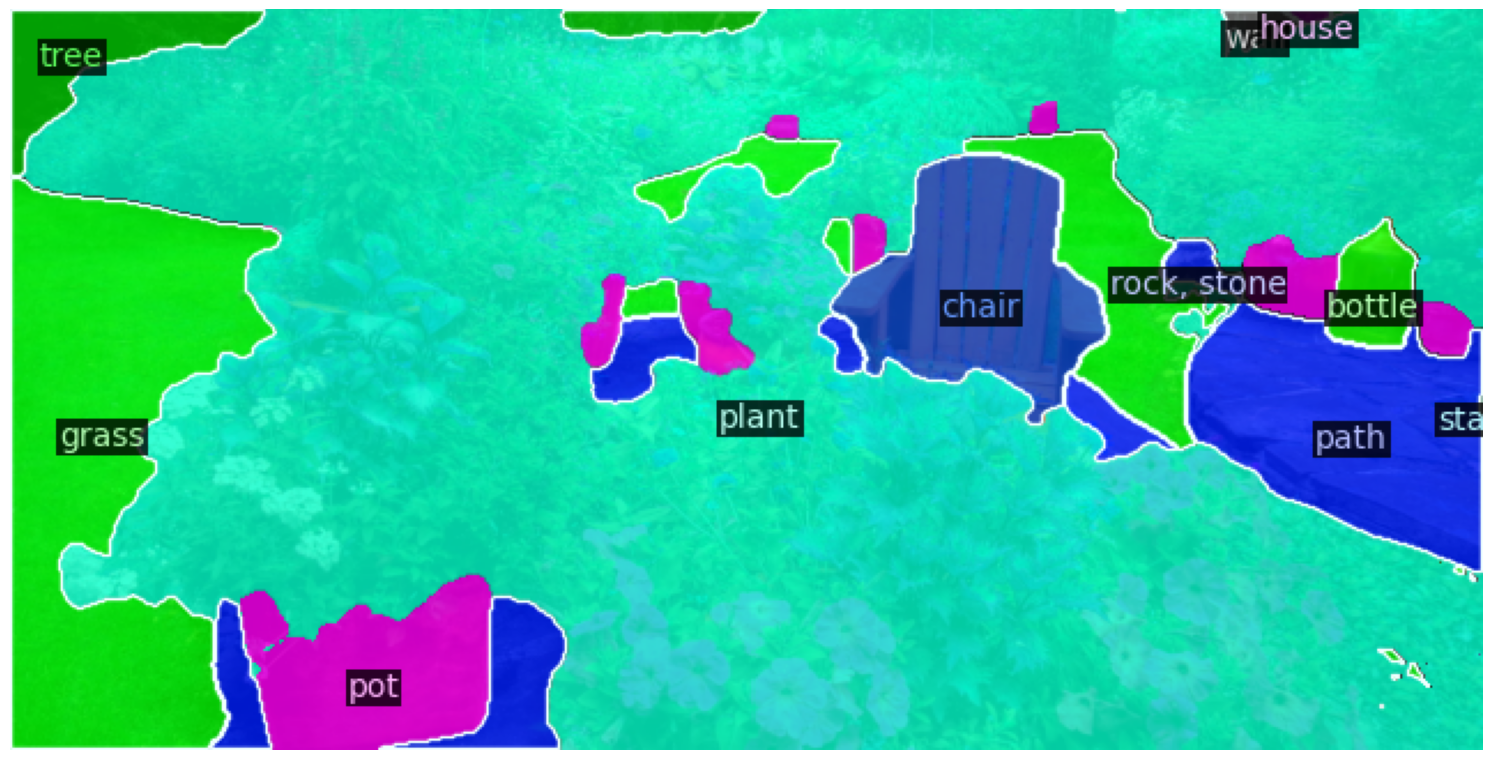

Saved colored overlay for garden.png to /home/sabbbir/Documents/of/OneFormer/seggpt/flower/out/ade/garden/garden_semantic_overlay.jpg


In [5]:
import os
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# Define input and output directories
input_dir = "/home/sabbbir/Documents/of/OneFormer/seggpt/flower"
# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/coco"
output_base_dir = "/home/sabbbir/Documents/of/OneFormer/seggpt/flower/out/ade"
# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/ade"


# predictor, metadata = coco()
# predictor, metadata = city()
predictor, metadata = ade()


# Ensure output base directory exists
os.makedirs(output_base_dir, exist_ok=True)
os.makedirs(input_dir, exist_ok=True)

# Get list of image files in input directory
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for img_file in image_files:
    # 1) Load & resize
    img_path = os.path.join(input_dir, img_file)
    img = cv2.imread(img_path)                    # BGR
    img = imutils.resize(img, width=640)

    # 2) Extract base name and make output dir
    image_name = os.path.splitext(img_file)[0]
    output_dir = os.path.join(output_base_dir, image_name, "semantic")
    os.makedirs(output_dir, exist_ok=True)

    # 3) Run predictor
    task = "semantic"
    outputs = predictor(img, task)
    print(f"Predictor returned keys for {img_file}:", outputs.keys())

    # 4) Decode logits → per-pixel class map
    sem_seg_logits = outputs["sem_seg"]
    class_map = sem_seg_logits.detach().cpu().argmax(0).numpy()  # (H, W)

    # 5) Save binary masks and red overlay for each non-background class
    unique_ids = np.unique(class_map)
    class_info = {}
    for class_id in unique_ids:
        if class_id == 0:
            continue
        # Get human-readable name
        class_name = metadata.stuff_classes[class_id] \
                     if hasattr(metadata, "stuff_classes") else f"class_{class_id}"
        class_info[class_id] = class_name

        # Save binary mask
        mask = (class_map == class_id).astype(np.uint8) * 255
        mask_path = os.path.join(output_dir, f"{class_name}_id_{class_id}.png")
        cv2.imwrite(mask_path, mask)

        # Save red overlay visualization
        overlay = img.copy()
        colored_mask = np.zeros_like(img)
        colored_mask[:, :, 2] = mask  # Red channel
        overlay = cv2.addWeighted(overlay, 0.7, colored_mask, 0.3, 0)
        vis_path = os.path.join(output_dir, f"{class_name}_id_{class_id}_vis.jpg")
        cv2.imwrite(vis_path, overlay)

    print(f"Found {len(class_info)} unique segments in {img_file}: {class_info.values()}")

    # 6) Build one nice colored overlay via Detectron2's Visualizer
    viz = Visualizer(
        img[:, :, ::-1],                # convert BGR→RGB for the Visualizer
        metadata=metadata,
        instance_mode=ColorMode.SEGMENTATION
    )
    out_viz = viz.draw_sem_seg(class_map)

    # 7) Extract BGR overlay, convert to RGB for Matplotlib
    overlay_bgr = out_viz.get_image()           # BGR
    overlay_rgb = overlay_bgr[:, :, ::-1]       # → RGB

    # 8) Display with Matplotlib
    plt.figure(figsize=(19, 10))
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.show()

    # 9) Save final overlay
    overlay_path = os.path.join(output_base_dir, image_name, f"{image_name}_semantic_overlay.jpg")
    cv2.imwrite(overlay_path, overlay_bgr)
    print(f"Saved colored overlay for {img_file} to {overlay_path}")

## Instance 

In [ ]:
import os
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# ─── 1. Define image directory and get all image files ────────────────────────
img_dir = "/home/sabbbir/Documents/of/OneFormer/seggpt/flower/inpt"

# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/coco"

# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/city"
# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/ade"
output_base_dir = "/home/sabbbir/Documents/of/OneFormer/seggpt/flower/out/coco/"

predictor, metadata = coco()
# predictor, metadata = city()
# predictor, metadata = ade()


img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
assert len(img_files) > 0, f"No images found in {img_dir}"

# ─── 2. Process each image ────────────────────────────────────────────────────
for img_file in img_files:
    img_path = os.path.join(img_dir, img_file)
    img = cv2.imread(img_path)
    assert img is not None, f"Failed to load {img_path}"
    img = imutils.resize(img, width=640)

    # ─── 3. Extract image name and create output directory ────────────────────
    image_name = os.path.splitext(img_file)[0]
    output_dir = os.path.join(output_base_dir, image_name, "instance")
    os.makedirs(output_dir, exist_ok=True)

    # ─── 4. Run instance-segmentation predictor ───────────────────────────────
    task = "instance"
    outputs = predictor(img, task)
    print(f"Predictor returned keys for {img_file}:", outputs.keys())

    # ─── 5. Unpack instance outputs ───────────────────────────────────────────
    instances    = outputs["instances"].to("cpu")
    pred_masks   = instances.pred_masks.numpy()    # (N, H, W)
    pred_classes = instances.pred_classes.numpy()  # (N,)
    scores       = instances.scores.numpy()        # (N,)

    # ─── 6. Save per-instance mask and overlay ────────────────────────────────
    class_info = {}
    for idx, (mask, cid, score) in enumerate(zip(pred_masks, pred_classes, scores)):
        class_name = metadata.thing_classes[cid]
        class_info[cid] = class_name

        # 6a) Save binary mask
        binary_mask = (mask.astype(np.uint8) * 255)
        mask_path = os.path.join(output_dir, f"{class_name}_id{cid}.png")
        cv2.imwrite(mask_path, binary_mask)

        # 6b) Save overlay visualization (red tint)
        overlay = img.copy()
        colored_mask = np.zeros_like(img)
        colored_mask[:, :, 2] = binary_mask
        overlay = cv2.addWeighted(overlay, 0.7, colored_mask, 0.3, 0)
        vis_path = os.path.join(output_dir, f"{class_name}_id_{cid}_vis.jpg")
        cv2.imwrite(vis_path, overlay)

    print(f"Found {len(class_info)} unique classes in {img_file}: {class_info.values()}")

    # ─── 7. Visualize full overlay with all instances ─────────────────────────
    viz = Visualizer(img[:, :, ::-1], metadata=metadata, instance_mode=ColorMode.SEGMENTATION)
    out_viz = viz.draw_instance_predictions(instances)
    overlay_bgr = out_viz.get_image()
    overlay_rgb = overlay_bgr[:, :, ::-1]

    # ─── 8. Show and save combined overlay ────────────────────────────────────
    plt.figure(figsize=(19, 10))
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.show()

    combined_path = os.path.join(output_dir, f"{image_name}_instance_overlay.jpg")
    cv2.imwrite(combined_path, overlay_bgr)
    print(f"Saved colored overlay to {combined_path}")

## Panoptic

In [ ]:
import os
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# 1) Define image directory and get all image files
# img_dir = "./seggpt/images/"
img_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/train/images/"
output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/coco"

# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/out/of_mask/city"
# output_base_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/tt/of_mask/ade"

predictor, metadata = coco()
# predictor, metadata = city()
# predictor, metadata = ade()
os.makedirs(output_base_dir, exist_ok=True)



img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

for img_file in img_files:
    # 2) Load & resize
    img_path = os.path.join(img_dir, img_file)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load image: {img_path}")
        continue
    img = imutils.resize(img, width=640)

    # 3) Extract image name and make output dir
    image_name = os.path.splitext(os.path.basename(img_path))[0]

    output_dir = os.path.join(output_base_dir, image_name, "panoptic")
    os.makedirs(output_dir, exist_ok=True)

    # 4) Run predictor
    task = "panoptic"
    outputs = predictor(img, task)
    print(f"Processing {img_file} - Predictor returned keys:", outputs.keys())

    # 5) Get panoptic map
    panoptic_seg, segments_info = outputs["panoptic_seg"]
    panoptic_np = panoptic_seg.detach().cpu().numpy()
    class_info = {}

    # 6) Save masks and overlays
    for seg in segments_info:
        sid = seg["id"]
        cid = seg["category_id"]
        isthing = seg["isthing"]
        
        # Determine class name based on whether it's a thing or stuff class
        try:
            class_name = metadata.thing_classes[cid] if isthing else metadata.stuff_classes[cid]
        except:
            class_name = f"class_{cid}"
        
        class_info[sid] = class_name

        # Save binary mask
        mask = (panoptic_np == sid).astype(np.uint8) * 255
        mask_path = os.path.join(output_dir, f"{class_name}_id_{cid}.png")
        cv2.imwrite(mask_path, mask)
        # print(f"Saved binary mask to {mask_path}")

        # Save overlay visualization (red tint)
        overlay = img.copy()
        # Create a red mask (BGR format)
        colored_mask = np.zeros_like(img)
        colored_mask[:, :, 2] = mask  # Set red channel to the binary mask
        # Blend the original image with the red mask
        overlay = cv2.addWeighted(overlay, 0.7, colored_mask, 0.3, 0)
        vis_path = os.path.join(output_dir, f"{class_name}_id_{cid}_vis.jpg")
        success = cv2.imwrite(vis_path, overlay)
        # if success:
        #     print(f"Saved red overlay to {vis_path}")
        # else:
        #     print(f"Failed to save red overlay to {vis_path}")

    print(f"Found {len(class_info)} unique segments for {img_file}: {class_info.values()}")

    # 7) Visualize full overlay
    viz = Visualizer(img[:, :, ::-1], metadata=metadata, instance_mode=ColorMode.SEGMENTATION)
    out_viz = viz.draw_panoptic_seg_predictions(panoptic_seg.cpu(), segments_info)
    overlay_bgr = out_viz.get_image()
    overlay_rgb = overlay_bgr[:, :, ::-1]

    # 8) Show and save
    plt.figure(figsize=(19, 10))
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.show()

    overlay_path = f"seggpt/masks/{image_name}/{image_name}_panoptic_overlay.jpg"
    cv2.imwrite(overlay_path, overlay_bgr)
    print(f"Saved colored overlay to {overlay_path}")

# SegGPT implementation + GT + Directory + Multiple GPU 

In [ ]:
# %% [markdown]
# # SegGPT Inference Setup (Multi-GPU via Multiprocessing)

# %%
import torch
from PIL import Image, ImageOps, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
from transformers import SegGptImageProcessor, SegGptForImageSegmentation
import os # <-- Added import for os.name check
import glob
import random
import gc
import time
# Import multiprocessing library
import multiprocessing as mp
from math import ceil # For splitting work

# %% [markdown]
# ## 1. Configuration

# %%
# --- Paths ---
# !!! PLEASE VERIFY THESE PATHS ARE CORRECT FOR YOUR SYSTEM !!!
reference_image_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/1_reference_image/images"
reference_mask_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/2_reference_mask_from_OF/masks"
target_image_dir = "/home/sabbbir/Documents/of/Brats_FT/brats/train/images" # Using Brats training images
coco_gt_mask_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/COCO GT/masks" # Verify matching logic

# --- Output ---
# Using common directories - ensure filenames are unique or create worker-specific dirs if needed
output_pred_mask_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/5_predicted_masks"
output_plot_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/7_output_plots"

# --- Settings ---
MASK_EXTENSION = ".png"
IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg"] # Add other extensions if needed for Brats
NUM_GPUS_TO_USE = 2 # How many GPUs you want to utilize
FIXED_REF_INDEX = 1 # Index of the reference pair in valid_ref_pairs to use for all predictions
PLOT_RESULTS = True # Set to False to disable plotting generation (might save memory/time)

# --- Setup COCO GT Usage ---
use_coco_gt = False
# IMPORTANT: Verify GT mask filename matching logic below if enabling this.
if coco_gt_mask_dir and os.path.isdir(coco_gt_mask_dir):
    use_coco_gt = True
    print(f"COCO Ground Truth masks will be attempted from: {coco_gt_mask_dir}")
    print("!!! WARNING: Ensure GT mask filenames match target image base names + '_mask.png' or adjust logic.")
else:
    print("COCO Ground Truth mask directory not provided or invalid. GT masks will not be used.")

# Create output directories if they don't exist
os.makedirs(output_pred_mask_dir, exist_ok=True)
os.makedirs(output_plot_dir, exist_ok=True)
print(f"Output predicted binary masks will be saved to: {output_pred_mask_dir}")
print(f"Output plots (2x3) will be saved to: {output_plot_dir}")


# %% [markdown]
# ## 2. Helper Functions

# %%
# Prepare Colormaps and Colors (once)
ref_overlay_color = np.array([1.0, 1.0, 0.0]) # Yellow for reference examples
ref_overlay_alpha = 0.6
gt_overlay_color = np.array([0.0, 1.0, 0.0]) # Lime Green for GT
gt_overlay_alpha = 0.7
# Define a distinct color for the prediction overlay in the comparison plot
pred_compare_color = np.array([1.0, 0.0, 0.0]) # Red for prediction
pred_compare_alpha = 0.5 # Alpha for prediction overlay

def create_overlay(image_np_float, mask_np, color_rgb, alpha_val):
    """ Overlays a single-color mask onto an image. """
    if image_np_float.shape[:2] != mask_np.shape:
         mask_pil = Image.fromarray(mask_np).resize(image_np_float.shape[:2][::-1], Image.NEAREST)
         mask_np = np.array(mask_pil)
         del mask_pil # Cleanup

    overlay = image_np_float.copy()
    # Ensure mask_np is boolean or 0/1 for alpha calculation
    mask_bool = (mask_np > 0) # Use threshold if mask is not binary (e.g., > 128 for L mode)
    mask_alpha = mask_bool.astype(np.float32) * alpha_val
    mask_color_rgb = np.tile(color_rgb[None, None, :], mask_np.shape + (1,))

    alpha_mask = mask_alpha[:, :, None] # Add channel dim for broadcasting
    overlay = (1 - alpha_mask) * overlay + alpha_mask * mask_color_rgb

    # Cleanup intermediate arrays
    del mask_alpha, mask_color_rgb, alpha_mask, mask_bool
    return np.clip(overlay, 0, 1)

# %% [markdown]
# ## 3. Worker Function (Executed by Each Process)

# %%
def worker_function(worker_id, total_workers, gpu_id, all_target_files, config):
    """
    Main processing function for a single worker process.
    Args:
        worker_id (int): ID of this worker (0-based).
        total_workers (int): Total number of workers.
        gpu_id (int): GPU ID assigned to this worker.
        all_target_files (list): List of all target image file paths.
        config (dict): Dictionary containing configuration paths and settings.
    """
    # --- Assign GPU Environment Variable ---
    # This MUST happen before torch CUDA initialization in this process
    # Handle case where no GPU is assigned (e.g., running on CPU)
    if gpu_id >= 0:
        os.environ['CUDA_VISIBLE_DEVICES'] = str(gpu_id)
        worker_prefix = f"[Worker {worker_id} | GPU {gpu_id}]"
    else:
        os.environ['CUDA_VISIBLE_DEVICES'] = "" # Ensure CUDA isn't accidentally used
        worker_prefix = f"[Worker {worker_id} | CPU]"

    print(f"{worker_prefix}: Process started.")

    # --- Unpack Config ---
    reference_image_dir = config['reference_image_dir']
    reference_mask_dir = config['reference_mask_dir']
    coco_gt_mask_dir = config['coco_gt_mask_dir']
    output_pred_mask_dir = config['output_pred_mask_dir']
    output_plot_dir = config['output_plot_dir']
    MASK_EXTENSION = config['MASK_EXTENSION']
    IMAGE_EXTENSIONS = config['IMAGE_EXTENSIONS']
    use_coco_gt = config['use_coco_gt']
    FIXED_REF_INDEX = config['FIXED_REF_INDEX']
    PLOT_RESULTS = config['PLOT_RESULTS']

    # --- Setup Model and Device ---
    print(f"{worker_prefix}: Loading model, processor, setting up device...")
    try:
        # Verify CUDA is available *after* setting env var
        # Use the assigned gpu_id if it's valid and CUDA is available
        device = "cpu"
        if gpu_id >= 0 and torch.cuda.is_available():
             # Check if the *specific* assigned GPU is visible after setting CUDA_VISIBLE_DEVICES
             # Note: After setting CUDA_VISIBLE_DEVICES=N, GPU N becomes device 'cuda:0' to torch
             if torch.cuda.device_count() > 0:
                 device = "cuda:0" # Always use cuda:0 as it's the only one visible
             else:
                 print(f"{worker_prefix}: WARNING - CUDA available but assigned GPU {gpu_id} not visible/found after setting env var. Using CPU.")
        elif gpu_id >= 0 and not torch.cuda.is_available():
            print(f"{worker_prefix}: WARNING - GPU {gpu_id} assigned, but CUDA not available. Using CPU.")
        else: # gpu_id was < 0
             print(f"{worker_prefix}: Running on CPU.")


        model_name = "BAAI/seggpt-vit-large"
        # Load models fresh in each process
        processor = SegGptImageProcessor.from_pretrained(model_name)
        model = SegGptForImageSegmentation.from_pretrained(model_name)
        model.to(device)
        print(f"{worker_prefix}: Using device: {device}")
    except Exception as e:
        print(f"{worker_prefix}: FATAL ERROR during model setup: {e}")
        return # Exit this worker process if model setup fails

    # --- Find Reference Pairs (Needed to select the fixed one) ---
    worker_all_ref_files = []
    for ext in IMAGE_EXTENSIONS:
        worker_all_ref_files.extend(glob.glob(os.path.join(reference_image_dir, ext)))
    worker_valid_ref_pairs = []
    for ref_img_path in worker_all_ref_files:
        ref_base = os.path.splitext(os.path.basename(ref_img_path))[0]
        # ref_base = os.path.splitext(os.path.basename(ref_img_path))[0]
        ref_mask_path = os.path.join(reference_mask_dir, ref_base + MASK_EXTENSION)
        if os.path.exists(ref_mask_path):
            worker_valid_ref_pairs.append({"image": ref_img_path, "mask": ref_mask_path})
    if not worker_valid_ref_pairs or FIXED_REF_INDEX >= len(worker_valid_ref_pairs):
        print(f"{worker_prefix}: FATAL ERROR - Cannot find enough valid reference pairs or invalid FIXED_REF_INDEX.")
        return
    prediction_ref_pair = worker_valid_ref_pairs[FIXED_REF_INDEX]
    print(f"{worker_prefix}: Using fixed reference pair index {FIXED_REF_INDEX}: Image='{os.path.basename(prediction_ref_pair['image'])}'")

    # --- Load Fixed Reference Pair ONCE ---
    try:
        pred_ref_image = Image.open(prediction_ref_pair['image']).convert("RGB")
        pred_ref_mask = Image.open(prediction_ref_pair['mask']).convert("L")
        if pred_ref_mask.size != pred_ref_image.size:
            pred_ref_mask = pred_ref_mask.resize(pred_ref_image.size, Image.NEAREST)
        print(f"{worker_prefix}: Fixed reference pair loaded.")
    except Exception as e:
        print(f"{worker_prefix}: FATAL ERROR loading fixed reference pair: {e}")
        return

    # --- Load Plotting Reference Data ONCE (Optional based on PLOT_RESULTS) ---
    plot_ref_data = []
    if PLOT_RESULTS:
        num_refs_to_plot = min(len(worker_valid_ref_pairs), 3)
        available_indices = list(range(len(worker_valid_ref_pairs)))
        if FIXED_REF_INDEX in available_indices:
            available_indices.remove(FIXED_REF_INDEX)
        if len(available_indices) >= num_refs_to_plot:
             plot_ref_indices = random.sample(available_indices, k=num_refs_to_plot)
        else: # Not enough other refs, sample from all including fixed ref
             plot_ref_indices = random.sample(range(len(worker_valid_ref_pairs)), k=num_refs_to_plot)

        plot_ref_pairs_info = [worker_valid_ref_pairs[i] for i in plot_ref_indices]
        print(f"{worker_prefix}: Loading {num_refs_to_plot} reference pairs for plotting examples...")
        for i, pair_info in enumerate(plot_ref_pairs_info):
            try:
                ref_img = Image.open(pair_info['image']).convert("RGB")
                ref_mask = Image.open(pair_info['mask']).convert("L")
                if ref_mask.size != ref_img.size:
                    ref_mask = ref_mask.resize(ref_img.size, Image.NEAREST)
                ref_img_np = np.array(ref_img).astype(np.float32) / 255.0
                ref_mask_np = np.array(ref_mask)
                ref_overlay = create_overlay(ref_img_np, ref_mask_np, ref_overlay_color, ref_overlay_alpha)
                plot_ref_data.append({
                    'overlay_np': ref_overlay, 'name': os.path.basename(pair_info['image'])
                })
                del ref_img, ref_mask, ref_img_np, ref_mask_np, ref_overlay # Aggressive cleanup
            except Exception as e:
                print(f"{worker_prefix}: Warning - Error loading plot reference {i}: {e}")
        while len(plot_ref_data) < 3: plot_ref_data.append(None) # Add placeholders


    # --- Determine Workload for this Worker ---
    num_files_total = len(all_target_files)
    num_files_per_worker = ceil(num_files_total / total_workers) # Use ceil for better distribution
    start_index = worker_id * num_files_per_worker
    end_index = min(start_index + num_files_per_worker, num_files_total) # Ensure end_index doesn't exceed total
    target_files_slice = all_target_files[start_index:end_index]

    print(f"{worker_prefix}: Processing images index {start_index} to {end_index-1} ({len(target_files_slice)} files).")

    # --- Main Processing Loop ---
    total_processed_worker = 0
    error_count_worker = 0
    for idx_slice, target_image_path in enumerate(target_files_slice):
        global_idx = start_index + idx_slice # For logging overall progress
        # Define temporary variables scoped to the loop iteration
        target_image = gt_mask_np = inputs = outputs = processed_output = None
        pred_mask = pred_mask_np = comparison_overlay_np = None
        fig = axes = None
        target_image_np_float = None # Ensure defined

        try:
            target_base_filename = os.path.splitext(os.path.basename(target_image_path))[0]
            print("-" * 40)
            print(f"{worker_prefix}: Processing TARGET {global_idx+1}/{num_files_total}: {os.path.basename(target_image_path)}")

            output_pred_mask_filename = os.path.join(output_pred_mask_dir, f"{target_base_filename}.png")
            output_plot_filename = os.path.join(output_plot_dir, f"plot_{target_base_filename}.png")

            # --- 4a. Load Target Image ---
            try:
                target_image = Image.open(target_image_path).convert("RGB")
                target_image_np_float = np.array(target_image).astype(np.float32) / 255.0
            except Exception as e:
                print(f"{worker_prefix}: ERROR loading target image {target_image_path}: {e}. Skipping.")
                error_count_worker += 1
                continue # Skip to next image

            # --- 4a-bis. Load Ground Truth Mask ---
            gt_mask_np = None # Initialize to None for each target
            if use_coco_gt:
                gt_mask_filename = f"{target_base_filename}_mask.png" # Example assumption
                gt_mask_path = os.path.join(coco_gt_mask_dir, gt_mask_filename)
                if os.path.exists(gt_mask_path):
                    try:
                        gt_mask_pil = Image.open(gt_mask_path).convert("L")
                        if gt_mask_pil.size != target_image.size:
                             gt_mask_pil = gt_mask_pil.resize(target_image.size, Image.NEAREST)
                        gt_mask_np_temp = np.array(gt_mask_pil)
                        gt_mask_np = ((gt_mask_np_temp > 128).astype(np.uint8) * 255) # Binarize
                        if not np.any(gt_mask_np): gt_mask_np = None # Treat all-black masks as None
                        del gt_mask_pil, gt_mask_np_temp
                    except Exception as e:
                        print(f"{worker_prefix}: Warning: Error loading/processing GT mask {gt_mask_path}: {e}")
                        gt_mask_np = None


            # --- 4b. Prepare Inputs ---
            try:
                inputs = processor(images=[target_image], prompt_images=[pred_ref_image], prompt_masks=[pred_ref_mask], return_tensors="pt")
                # Send inputs to the correct device for this worker
                inputs = {k: v.to(device) for k, v in inputs.items()}
            except Exception as e:
                 print(f"{worker_prefix}: ERROR during processor input preparation: {e}. Skipping.")
                 error_count_worker += 1
                 del target_image, target_image_np_float
                 if gt_mask_np is not None: del gt_mask_np
                 continue

            # --- 4c. Run Inference ---
            pred_mask = pred_mask_np = None # Ensure reset before inference
            try:
                with torch.no_grad(): outputs = model(**inputs)
                target_sizes = [target_image.size[::-1]] # H, W format
                processed_output = processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)

                if isinstance(processed_output, list) and len(processed_output) > 0:
                    mask_data = processed_output[0]
                    if isinstance(mask_data, torch.Tensor):
                        pred_mask_tensor = mask_data.cpu().squeeze()
                        pred_mask_np_interim = (pred_mask_tensor.numpy() > 0.5).astype(np.uint8) * 255
                        pred_mask = Image.fromarray(pred_mask_np_interim, mode='L')
                        pred_mask_np = pred_mask_np_interim
                        del pred_mask_tensor, pred_mask_np_interim
                    elif isinstance(mask_data, Image.Image):
                        pred_mask = mask_data.convert('L')
                        pred_mask_np = np.array(pred_mask)
                    else:
                        print(f"{worker_prefix}: Unexpected mask format in processed_output: {type(mask_data)}")

                del outputs, processed_output, inputs
                if 'mask_data' in locals(): del mask_data
                if 'pred_mask_tensor' in locals(): del pred_mask_tensor

                if pred_mask is None or pred_mask_np is None:
                    print(f"{worker_prefix}: Inference failed to produce a valid mask. Skipping.")
                    error_count_worker += 1
                    del target_image, target_image_np_float
                    if gt_mask_np is not None: del gt_mask_np
                    if device.startswith('cuda'): torch.cuda.empty_cache()
                    continue

            except Exception as e:
                print(f"{worker_prefix}: ERROR during inference or post-processing: {e}")
                error_count_worker += 1
                if 'outputs' in locals(): del outputs
                if 'processed_output' in locals(): del processed_output
                if 'inputs' in locals(): del inputs
                if 'mask_data' in locals(): del mask_data
                if 'pred_mask_tensor' in locals(): del pred_mask_tensor
                if 'pred_mask' in locals(): del pred_mask
                if 'pred_mask_np' in locals(): del pred_mask_np
                del target_image, target_image_np_float
                if gt_mask_np is not None: del gt_mask_np
                if device.startswith('cuda'): torch.cuda.empty_cache()
                continue

            # --- 4d. Save Predicted Mask ---
            try:
                pred_mask.save(output_pred_mask_filename)
            except Exception as e:
                print(f"{worker_prefix}: Warning: Error saving predicted mask {output_pred_mask_filename}: {e}")

            # --- 4e/4e-bis. Create Overlays for Comparison Plot ---
            comparison_overlay_np = None # Initialize
            plot_title_suffix = "" # For the comparison plot title
            try:
                current_overlay = target_image_np_float.copy()
                title_parts = ["Target"]

                if gt_mask_np is not None:
                    current_overlay = create_overlay(current_overlay, gt_mask_np, gt_overlay_color, gt_overlay_alpha)
                    title_parts.append("GT (Lime)")

                if pred_mask_np is not None:
                    current_overlay = create_overlay(current_overlay, pred_mask_np, pred_compare_color, pred_compare_alpha)
                    title_parts.append("Pred (Red)")
                else:
                     print(f"{worker_prefix}: Warning: pred_mask_np is None, cannot overlay prediction for plot.")

                comparison_overlay_np = current_overlay
                plot_title_suffix = " + ".join(title_parts)
                del current_overlay

            except Exception as e:
                print(f"{worker_prefix}: Warning: Error creating comparison overlay: {e}")
                if comparison_overlay_np is None:
                    comparison_overlay_np = target_image_np_float
                    plot_title_suffix = "Target (Overlay Error)"

            # --- 4f. Create and Save Plot (Optional) ---
            if PLOT_RESULTS:
                fig = axes = None
                try:
                    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
                    fig.suptitle(f"Segmentation Result for: {os.path.basename(target_image_path)}\n(Worker {worker_id} | Using Single Ref: {os.path.basename(prediction_ref_pair['image'])})", fontsize=14)

                    # Row 1: Reference Examples
                    for i in range(3):
                        ax = axes[0, i]
                        if i < len(plot_ref_data) and plot_ref_data[i] is not None:
                            ax.imshow(plot_ref_data[i]['overlay_np'])
                            ax.set_title(f"Ref Example {i+1}: {plot_ref_data[i]['name']}")
                        else:
                            ax.set_title(f"Ref Example {i+1}: N/A")
                            ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('lightgray')
                        ax.axis('off')

                    # Row 2: Target, Prediction Mask, Comparison Overlay
                    axes[1, 0].imshow(target_image_np_float)
                    axes[1, 0].set_title("Target Image"); axes[1, 0].axis('off')

                    if pred_mask_np is not None:
                        axes[1, 1].imshow(pred_mask_np, cmap='gray', vmin=0, vmax=255)
                        axes[1, 1].set_title("Predicted Mask"); axes[1, 1].axis('off')
                    else:
                        axes[1, 1].set_title("Predicted Mask (Error)"); axes[1, 1].axis('off')
                        axes[1, 1].set_facecolor('lightcoral')

                    axes[1, 2].imshow(comparison_overlay_np)
                    axes[1, 2].set_title(plot_title_suffix); axes[1, 2].axis('off')

                    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                    plt.savefig(output_plot_filename)
                    plt.close(fig)
                    del fig, axes

                except Exception as plot_save_e:
                    print(f"{worker_prefix}: ERROR during plotting or saving plot: {plot_save_e}")
                    error_count_worker += 1
                    if fig is not None: plt.close(fig)
                    if 'fig' in locals(): del fig
                    if 'axes' in locals(): del axes

            # Increment success counter AFTER potential plotting
            total_processed_worker += 1

        except Exception as outer_e:
            print(f"{worker_prefix}: UNEXPECTED loop ERROR processing target {target_image_path}: {outer_e}")
            error_count_worker += 1
            if 'fig' in locals() and fig is not None: plt.close(fig)

        finally:
            # Cleanup at the end of each loop iteration
            del target_image, gt_mask_np, pred_mask, pred_mask_np
            if 'target_image_np_float' in locals(): del target_image_np_float
            if 'comparison_overlay_np' in locals(): del comparison_overlay_np
            if 'fig' in locals() and fig is not None : del fig
            if 'axes' in locals(): del axes
            collected = gc.collect()
            if device.startswith('cuda'): torch.cuda.empty_cache()


    # --- Worker Finished ---
    print(f"{worker_prefix}: --- Worker Finished ---")
    print(f"{worker_prefix}: Successfully processed {total_processed_worker} images.")
    print(f"{worker_prefix}: Encountered errors on {error_count_worker} images.")
    del model, processor, pred_ref_image, pred_ref_mask, plot_ref_data
    gc.collect()
    if device.startswith('cuda'): torch.cuda.empty_cache()


# %% [markdown]
# ## 4. Main Execution Block (Starts Worker Processes)

# %%
# This block should be executed when you want to run the parallel processing
if __name__ == '__main__': # Important for multiprocessing
    print("--- Main Process: Starting Multi-GPU Inference ---")
    start_time = time.time()

    # --- Check GPU Availability ---
    available_gpus = torch.cuda.device_count()
    print(f"Main Process: Found {available_gpus} available GPUs.")
    if available_gpus == 0:
        print("Main Process: No GPUs found. Consider running on CPU (will be slow).")
        if NUM_GPUS_TO_USE > 1:
            print(f"Main Process: WARNING - Requesting {NUM_GPUS_TO_USE} workers but only CPU available. Will run {NUM_GPUS_TO_USE} processes on CPU.")
    elif available_gpus < NUM_GPUS_TO_USE:
        print(f"Main Process: Warning - Requested {NUM_GPUS_TO_USE} GPUs, but only {available_gpus} available. Using {available_gpus}.")
        NUM_GPUS_TO_USE = available_gpus

    if NUM_GPUS_TO_USE <= 0:
        print("Main Process: No workers to start. Exiting.")
        exit()

    # --- Prepare Data and Config for Workers ---
    print("Main Process: Finding target image files...")
    all_target_image_files = []
    for ext in IMAGE_EXTENSIONS:
        all_target_image_files.extend(glob.glob(os.path.join(target_image_dir, ext)))
    if not all_target_image_files:
        print("Main Process: Error - No target image files found. Exiting.")
        exit()
    print(f"Main Process: Found {len(all_target_image_files)} total target images.")

    all_target_image_files.sort()

    config = {
        'reference_image_dir': reference_image_dir,
        'reference_mask_dir': reference_mask_dir,
        'coco_gt_mask_dir': coco_gt_mask_dir,
        'output_pred_mask_dir': output_pred_mask_dir,
        'output_plot_dir': output_plot_dir,
        'MASK_EXTENSION': MASK_EXTENSION,
        'IMAGE_EXTENSIONS': IMAGE_EXTENSIONS,
        'use_coco_gt': use_coco_gt,
        'FIXED_REF_INDEX': FIXED_REF_INDEX,
        'PLOT_RESULTS': PLOT_RESULTS
    }

    # --- Start Worker Processes ---
    processes = []
    print(f"Main Process: Starting {NUM_GPUS_TO_USE} worker processes...")

    # <<< CHANGE MADE HERE: Attempt to force 'fork' if on Linux/macOS >>>
    # This is a potential workaround if running directly from the terminal still fails
    # due to the environment forcing 'spawn'. 'fork' is generally less safe with CUDA
    # but might resolve the AttributeError if 'spawn' cannot find the function.
    try:
        # Check if on a Unix-like system (Linux, macOS) where 'fork' is available
        if os.name == 'posix':
             # Check if the current start method isn't already 'fork'
             current_method = mp.get_start_method(allow_none=True)
             if current_method != 'fork':
                 mp.set_start_method('fork', force=True)
                 print("Main Process: Explicitly set start method to 'fork' as a workaround.")
             else:
                 print("Main Process: Start method already 'fork'. Using it.")
        else:
             print("Main Process: Not on POSIX system. Using default multiprocessing start method (likely 'spawn' on Windows).")
    except RuntimeError as e:
        print(f"Main Process: Warning - Could not set start method to 'fork': {e}. Using default.")
    except ValueError as e:
         print(f"Main Process: Warning - Start method 'fork' might not be available or already set: {e}. Using default.")
    except Exception as e: # Catch other potential issues
        print(f"Main Process: An unexpected error occurred while setting start method: {e}. Using default.")


    for worker_id in range(NUM_GPUS_TO_USE):
        gpu_id = worker_id if available_gpus > 0 else -1
        process = mp.Process(target=worker_function, args=(
            worker_id,
            NUM_GPUS_TO_USE,
            gpu_id,
            all_target_image_files,
            config
        ))
        processes.append(process)
        process.start()

    # --- Wait for Workers to Finish ---
    print("Main Process: Waiting for worker processes to complete...")
    for process in processes:
        process.join()

    # --- All Done ---
    end_time = time.time()
    total_time = end_time - start_time
    print("-" * 50)
    print(f"Main Process: All workers finished.")
    print(f"Total execution time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    if len(all_target_image_files) > 0 and total_time > 0:
        print(f"Average time per image: {total_time / len(all_target_image_files):.3f} seconds")
    print("-" * 50)

# Scores and Benchmark

In [ ]:
import os
import glob
from PIL import Image
import numpy as np
from sklearn.metrics import (
    jaccard_score,  # IoU
    f1_score,       # Dice
    accuracy_score, # Pixel Accuracy
    precision_score,
    recall_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # For easier handling of metrics

# --- Configuration ---
pred_mask_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/5_predicted_masks"
gt_mask_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/COCO GT/masks"
# Optional: Original image dir if needed later, but not required for metrics
# target_image_dir = "/home/druglord/Remote/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/3_target_image_s/images"

# Directory to save plots
output_plot_dir = "/home/sabbbir/Documents/of/OneFormer/IMPLEMENTATION/2_SegGPT/evaluation_plots_1112"
os.makedirs(output_plot_dir, exist_ok=True)

# Mask properties
GT_SUFFIX = "_mask.png"
PRED_EXTENSION = ".png" # Assuming prediction masks are png
POSITIVE_CLASS_LABEL = 1 # Assuming foreground is 1 after binarization

# --- Helper Function ---
def load_and_binarize_mask(mask_path, target_size=None):
    """Loads a mask, optionally resizes, and converts to binary 0/1 numpy array."""
    try:
        mask = Image.open(mask_path).convert('L') # Convert to grayscale
        if target_size and mask.size != target_size:
            print(f"    Warning: Resizing mask {os.path.basename(mask_path)} from {mask.size} to {target_size}")
            mask = mask.resize(target_size, Image.NEAREST)

        mask_np = np.array(mask)
        # Binarize: Assume non-zero pixels are foreground (adjust threshold if needed)
        binary_mask = (mask_np > 128).astype(np.uint8) # Use 128 as common threshold
        return binary_mask
    except FileNotFoundError:
        print(f"    Error: Mask file not found: {mask_path}")
        return None
    except Exception as e:
        print(f"    Error loading/processing mask {mask_path}: {e}")
        return None

# --- Find prediction files and match with GT ---
print(f"Searching for predicted masks in: {pred_mask_dir}")
pred_mask_files = glob.glob(os.path.join(pred_mask_dir, f"*{PRED_EXTENSION}"))
print(f"Found {len(pred_mask_files)} predicted mask files.")

if not pred_mask_files:
    print("Error: No prediction files found. Exiting.")
    exit()

results = [] # Store results for each image pair

print("\nProcessing image pairs and calculating metrics...")
processed_count = 0
skipped_count = 0

for pred_path in pred_mask_files:
    pred_basename = os.path.basename(pred_path)
    base_name_no_ext = os.path.splitext(pred_basename)[0]

    gt_filename = f"{base_name_no_ext}{GT_SUFFIX}"
    gt_path = os.path.join(gt_mask_dir, gt_filename)

    print(f"  Processing: Pred='{pred_basename}', Expecting GT='{gt_filename}'")

    if not os.path.exists(gt_path):
        print(f"    Warning: Corresponding GT mask not found. Skipping.")
        skipped_count += 1
        continue

    # Load prediction mask first to get target size (optional, safer)
    pred_mask_np = load_and_binarize_mask(pred_path)
    if pred_mask_np is None:
        skipped_count += 1
        continue

    # Load GT mask, resizing to match prediction if necessary
    # Note: It's generally better if they are already the same size.
    # Resizing GT can slightly affect metrics.
    gt_mask_np = load_and_binarize_mask(gt_path, target_size=(pred_mask_np.shape[1], pred_mask_np.shape[0])) # W, H for PIL size
    if gt_mask_np is None:
        skipped_count += 1
        continue

    # Ensure masks have the same shape after loading and potential resize
    if pred_mask_np.shape != gt_mask_np.shape:
        print(f"    Error: Mask shapes mismatch after loading/resizing ({pred_mask_np.shape} vs {gt_mask_np.shape}). Skipping.")
        skipped_count += 1
        continue

    # Flatten arrays for sklearn metrics
    pred_flat = pred_mask_np.flatten()
    gt_flat = gt_mask_np.flatten()

    # Handle case where GT mask is all background (avoid division by zero in some metrics)
    if np.sum(gt_flat) == 0:
        print("    Note: GT mask is empty (all background).")
        # If prediction is also empty, IoU/Dice are often defined as 1.
        # If prediction is not empty, IoU/Dice are 0.
        iou_score = 1.0 if np.sum(pred_flat) == 0 else 0.0
        dice_score = 1.0 if np.sum(pred_flat) == 0 else 0.0
        # Precision is undefined (0/0) if pred is empty, 0 if pred has FPs.
        precision = 1.0 if np.sum(pred_flat) == 0 else 0.0 # Convention: Perfect precision if nothing predicted for empty GT
        recall = 1.0 # Convention: Found all "zero" positive pixels
        accuracy = accuracy_score(gt_flat, pred_flat) # Still calculable
        tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat, labels=[0, POSITIVE_CLASS_LABEL]).ravel()

    # Handle case where prediction mask is all background
    elif np.sum(pred_flat) == 0:
        print("    Note: Predicted mask is empty (all background).")
        iou_score = 0.0 # FN > 0 (unless GT also empty)
        dice_score = 0.0
        precision = 1.0 # Convention: Perfect precision if nothing predicted
        # Recall is 0 because TP = 0 and FN > 0
        recall = 0.0
        accuracy = accuracy_score(gt_flat, pred_flat)
        tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat, labels=[0, POSITIVE_CLASS_LABEL]).ravel()

    # Normal case: Both masks potentially have foreground pixels
    else:
        try:
            # Calculate standard metrics
            # Use pos_label=POSITIVE_CLASS_LABEL (usually 1)
            # zero_division=0 means metric is 0 if denominator is 0 (e.g., Precision=0 if TP+FP=0)
            iou_score = jaccard_score(gt_flat, pred_flat, pos_label=POSITIVE_CLASS_LABEL, average='binary', zero_division=0)
            dice_score = f1_score(gt_flat, pred_flat, pos_label=POSITIVE_CLASS_LABEL, average='binary', zero_division=0)
            accuracy = accuracy_score(gt_flat, pred_flat)
            precision = precision_score(gt_flat, pred_flat, pos_label=POSITIVE_CLASS_LABEL, average='binary', zero_division=0)
            recall = recall_score(gt_flat, pred_flat, pos_label=POSITIVE_CLASS_LABEL, average='binary', zero_division=0)
            tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat, labels=[0, POSITIVE_CLASS_LABEL]).ravel()

        except Exception as e:
            print(f"    Error calculating metrics for {pred_basename}: {e}. Skipping.")
            skipped_count += 1
            continue

    # Store results
    results.append({
        'filename': base_name_no_ext,
        'iou': iou_score,
        'dice': dice_score,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'gt_size': np.sum(gt_flat) # Store GT object size
    })
    processed_count += 1
    # print(f"    Metrics: IoU={iou_score:.4f}, Dice={dice_score:.4f}, Acc={accuracy:.4f}") # Verbose

print(f"\nFinished processing. Successfully processed {processed_count} pairs, skipped {skipped_count}.")

# --- Analyze and Plot Results ---
if not results:
    print("\nNo results to analyze. Exiting.")
    exit()

# Create a Pandas DataFrame for easier analysis
results_df = pd.DataFrame(results)

print("\n--- Overall Performance Metrics ---")
print(f"Mean IoU:      {results_df['iou'].mean():.4f} (+/- {results_df['iou'].std():.4f})")
print(f"Median IoU:    {results_df['iou'].median():.4f}")
print(f"Mean Dice:     {results_df['dice'].mean():.4f} (+/- {results_df['dice'].std():.4f})")
print(f"Median Dice:   {results_df['dice'].median():.4f}")
print(f"Mean Accuracy: {results_df['accuracy'].mean():.4f} (+/- {results_df['accuracy'].std():.4f})")
print(f"Mean Precision:{results_df['precision'].mean():.4f} (+/- {results_df['precision'].std():.4f})")
print(f"Mean Recall:   {results_df['recall'].mean():.4f} (+/- {results_df['recall'].std():.4f})")

# --- Generate Plots ---
print(f"\nGenerating plots in: {output_plot_dir}")

plt.style.use('seaborn-v0_8-whitegrid') # Use a clean style

# 1. Distribution of IoU Scores
plt.figure(figsize=(10, 6))
sns.histplot(results_df['iou'], bins=20, kde=True)
plt.title('Distribution of IoU Scores', fontsize=16)
plt.xlabel('IoU Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 1)
plt.axvline(results_df['iou'].mean(), color='r', linestyle='--', label=f"Mean: {results_df['iou'].mean():.3f}")
plt.axvline(results_df['iou'].median(), color='g', linestyle=':', label=f"Median: {results_df['iou'].median():.3f}")
plt.legend()
plt.savefig(os.path.join(output_plot_dir, 'iou_distribution.png'), dpi=300)
plt.close()
print("  Saved iou_distribution.png")

# 2. Distribution of Dice Scores
plt.figure(figsize=(10, 6))
sns.histplot(results_df['dice'], bins=20, kde=True)
plt.title('Distribution of Dice Scores', fontsize=16)
plt.xlabel('Dice Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 1)
plt.axvline(results_df['dice'].mean(), color='r', linestyle='--', label=f"Mean: {results_df['dice'].mean():.3f}")
plt.axvline(results_df['dice'].median(), color='g', linestyle=':', label=f"Median: {results_df['dice'].median():.3f}")
plt.legend()
plt.savefig(os.path.join(output_plot_dir, 'dice_distribution.png'), dpi=300)
plt.close()
print("  Saved dice_distribution.png")

# 3. Box Plot of IoU and Dice Scores
plt.figure(figsize=(8, 6))
sns.boxplot(data=results_df[['iou', 'dice']], palette='pastel')
plt.title('Box Plot of IoU and Dice Scores', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.savefig(os.path.join(output_plot_dir, 'iou_dice_boxplot.png'), dpi=300)
plt.close()
print("  Saved iou_dice_boxplot.png")

# 4. Scatter Plot: IoU vs. GT Object Size (if GT size varies)
# Filter out images where GT size is 0 for this plot if many exist
plot_df_size = results_df[results_df['gt_size'] > 0]
if not plot_df_size.empty:
    plt.figure(figsize=(10, 6))
    # Use log scale for size if it varies widely
    use_log_scale = plot_df_size['gt_size'].max() / max(1, plot_df_size['gt_size'].min()) > 100
    ax = sns.scatterplot(x='gt_size', y='iou', data=plot_df_size, alpha=0.6)
    plt.title('IoU Score vs. Ground Truth Object Size', fontsize=16)
    plt.ylabel('IoU Score', fontsize=12)
    plt.xlabel(f'GT Object Size (pixels{" - Log Scale" if use_log_scale else ""})', fontsize=12)
    plt.ylim(0, 1.05)
    if use_log_scale:
        ax.set_xscale('log')
    plt.savefig(os.path.join(output_plot_dir, 'iou_vs_gt_size_scatter.png'), dpi=300)
    plt.close()
    print("  Saved iou_vs_gt_size_scatter.png")
else:
    print("  Skipping IoU vs GT Size plot (no GT objects found or all have size 0).")


# --- Identify Best/Worst Cases ---
print("\n--- Example Cases for Qualitative Review ---")
results_df_sorted_iou = results_df.sort_values(by='iou', ascending=False)

# Best IoU cases
print("\nTop 5 Best Performing Images (by IoU):")
for i, row in results_df_sorted_iou.head(5).iterrows():
    print(f"  - File: {row['filename']}{PRED_EXTENSION}, IoU: {row['iou']:.4f}, Dice: {row['dice']:.4f}")

# Worst IoU cases
print("\nTop 5 Worst Performing Images (by IoU):")
for i, row in results_df_sorted_iou.tail(5).iloc[::-1].iterrows(): # Reverse tail for worst first
    print(f"  - File: {row['filename']}{PRED_EXTENSION}, IoU: {row['iou']:.4f}, Dice: {row['dice']:.4f}")


print("\nEvaluation complete.")